# 03 — Feature Engineering & Importance Analysis

**Owner:** Benek — *Feature Engineering & Classical ML*

This notebook builds the per-trade feature set defined in [`src/features.py`](../src/features.py) and analyses which
features actually carry signal. It uses **only `(price, amount, time)`** — no order book — so every feature here is
available at inference time when the professor runs `classify_side` on unseen trades.

**What this notebook does, step by step:**
1. Load trades (both symbols) and build the full 23-feature matrix
2. Catalogue every feature and check NaN coverage at window boundaries
3. Visualise each key feature's distribution **split by aggressor side** (signal vs noise)
4. Rank features by linear correlation with the label (point-biserial *r*)
5. Rank features by non-linear importance (LightGBM gain)
6. Ablate low-importance features and confirm the reduced set holds up
7. Test cross-symbol generalisation (the closest proxy we have for "unseen data")
8. Summarise findings and recommend a feature set for the GBM and sequence models

> **Reproducibility:** a global `SEED` is set and LightGBM runs single-threaded (`num_threads=1`).
> Multi-threaded LightGBM is *not* deterministic even with a fixed seed, so this matters — results are now stable across reruns.

## 0. Setup & reproducibility

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
import lightgbm as lgb

from src.data import load_split, DATES, SYMBOLS
from src.features import build_features, FEATURE_NAMES
from src.baselines import tick_rule
from src.evaluate import metrics

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# global seed — used everywhere below for reproducible results
SEED = 42
np.random.seed(SEED)

# LightGBM params shared across every model in this notebook.
# num_threads=1 forces single-threaded training => fully reproducible.
LGB_PARAMS = {
    'objective':     'binary',
    'metric':        'binary_logloss',
    'num_leaves':    31,
    'learning_rate': 0.05,
    'verbose':       -1,
    'seed':          SEED,
    'num_threads':   1,
}

print(f"Train: {DATES['train']}   Val: {DATES['val']}   Test (untouched): {DATES['test']}")
print(f"Symbols: {SYMBOLS}")

Train: 2026-04-12   Val: 2026-04-13   Test (untouched): 2026-04-14
Symbols: ['WIFUSDT', 'ZAMAUSDT']


## 1. Load data & build features

We load the **train** split (2026-04-12) and **val** split (2026-04-13) for both symbols, then run
`build_features` on each. The test split (2026-04-14) is deliberately left untouched until the very end of the project.

In [2]:
train_data = load_split('train')   # {symbol: trades_df}
val_data   = load_split('val')

feats_train = {sym: build_features(df) for sym, df in train_data.items()}
feats_val   = {sym: build_features(df) for sym, df in val_data.items()}

for sym in SYMBOLS:
    print(f"{sym:10s}  train: {len(train_data[sym]):>7,} rows   "
          f"val: {len(val_data[sym]):>7,} rows   "
          f"features: {feats_train[sym].shape[1]}")

WIFUSDT     train:  10,805 rows   val:  14,868 rows   features: 23
ZAMAUSDT    train:  31,162 rows   val:  32,408 rows   features: 23


### Feature catalogue

All 23 features, grouped by what they capture. Every one is computed with **strict no-look-ahead** — at row *t* only
rows 0..*t* are used, so nothing leaks from the future.

| Group | Features | What it captures |
|---|---|---|
| **Tick direction** | `tick_1`…`tick_5`, `tick_ff` | Sign of price change at lags 1-5; `tick_ff` = forward-filled non-zero tick (the raw tick rule) |
| **Log-returns** | `ret_1`, `ret_3`, `ret_5`, `ret_10` | Price momentum over 1/3/5/10 trades |
| **Time gaps** | `dt_s`, `log_dt_s` | Seconds since previous trade, and its log (busy vs quiet regime) |
| **Volume** | `vol_z_10/20/50`, `log_amount` | Rolling z-score of trade size over 10/20/50 trades; log size |
| **Streaks** | `run_length`, `run_dir` | How many consecutive same-direction ticks, and that direction |
| **Price position** | `pct_range_20`, `pct_range_50` | Where price sits in its recent 20/50-trade high-low range (0=low, 1=high) |
| **Round numbers** | `frac_price`, `round_prox`, `log_price` | Proximity to round price levels; absolute price level |

Below: descriptive statistics for ZAMAUSDT (train).

In [3]:
feats_train['ZAMAUSDT'].describe().T

,count,mean,std,min,25%,50%,75%,max
tick_1,31161.0000,-0.0080,0.5388,-1.0000,0.0000,0.0000,0.0000,1.0000
tick_2,31160.0000,-0.0133,0.6749,-1.0000,0.0000,0.0000,0.0000,1.0000
tick_3,31159.0000,-0.0166,0.7468,-1.0000,-1.0000,0.0000,1.0000,1.0000
tick_4,31158.0000,-0.0166,0.7927,-1.0000,-1.0000,0.0000,1.0000,1.0000
tick_5,31157.0000,-0.0158,0.8217,-1.0000,-1.0000,0.0000,1.0000,1.0000
tick_ff,31162.0000,-0.0184,0.9998,-1.0000,-1.0000,-1.0000,1.0000,1.0000
ret_1,31161.0000,-0.0000,0.0003,-0.0036,0.0000,0.0000,0.0000,0.0029
ret_3,31159.0000,-0.0000,0.0005,-0.0040,-0.0004,0.0000,0.0004,0.0036
ret_5,31157.0000,-0.0000,0.0007,-0.0036,-0.0004,0.0000,0.0004,0.0044
ret_10,31152.0000,-0.0000,0.0010,-0.0054,-0.0008,0.0000,0.0004,0.0052


## 2. NaN coverage

Window-based features (returns, rolling stats, lagged ticks) are undefined for the first few trades of the day.
We check how many rows that costs — if it's tiny, we can safely drop those rows when training.

In [4]:
for sym in SYMBOLS:
    nan_pct = feats_train[sym].isna().mean().sort_values(ascending=False)
    nan_pct = nan_pct[nan_pct > 0]
    print(f"\n{sym} — features with any NaN (% of rows):")
    print(nan_pct.apply(lambda x: f'{x*100:.2f}%').to_string() if len(nan_pct) else '  (none)')


WIFUSDT — features with any NaN (% of rows):
ret_10      0.09%
ret_5       0.05%
tick_5      0.05%
tick_4      0.04%
ret_3       0.03%
tick_3      0.03%
tick_2      0.02%
vol_z_10    0.01%
ret_1       0.01%
tick_1      0.01%
dt_s        0.01%
vol_z_50    0.01%
vol_z_20    0.01%

ZAMAUSDT — features with any NaN (% of rows):
ret_10      0.03%
ret_5       0.02%
tick_5      0.02%
tick_4      0.01%
ret_3       0.01%
tick_3      0.01%
tick_2      0.01%
vol_z_10    0.00%
ret_1       0.00%
tick_1      0.00%
dt_s        0.00%
vol_z_50    0.00%
vol_z_20    0.00%


## 3. Label-separated feature distributions

### What we are doing
For 10 key features we overlay two **density histograms**:
- **Blue (Buy)** — feature values where a *buyer* was the aggressor (`side = False`)
- **Red (Sell)** — feature values where a *seller* was the aggressor (`side = True`)

Both are densities (area = 1) so the ~52/48 class imbalance doesn't distort the picture, and the x-axis is clipped to
the 1st–99th percentile to remove outliers.

### How to read each panel
| Pattern | Meaning |
|---|---|
| Peaks at clearly different positions | **Strong signal** — the feature shifts by aggressor side |
| Histograms largely overlap | **No signal** — noise for any classifier |
| One curve shifted left/right of the other | **Linear signal** — useful even for logistic regression |
| Different *shapes* (e.g. bimodal vs unimodal) | **Non-linear signal** — a tree model exploits it, a linear one may not |

### What to expect
- **`tick_1`, `tick_ff`** — clearest separation: sells cluster at −1 (price fell), buys at +1. This *is* the tick rule.
- **`ret_1`, `ret_3`** — continuous version of the above; negative returns → sell, positive → buy.
- **`pct_range_20`** — buys near 1 (lifting offers at recent highs), sells near 0 (hitting bids at lows). Strongest correlate.
- **`run_length`** — right-skewed; look for a tail-shift between labels.
- **`log_dt_s`, `vol_z_10`** — weak/regime features; expect heavy overlap.
- **`frac_price`, `round_prox`** — round-number proximity; expect little separation (and these don't transfer across symbols).

**Separation = signal; overlap = noise.**

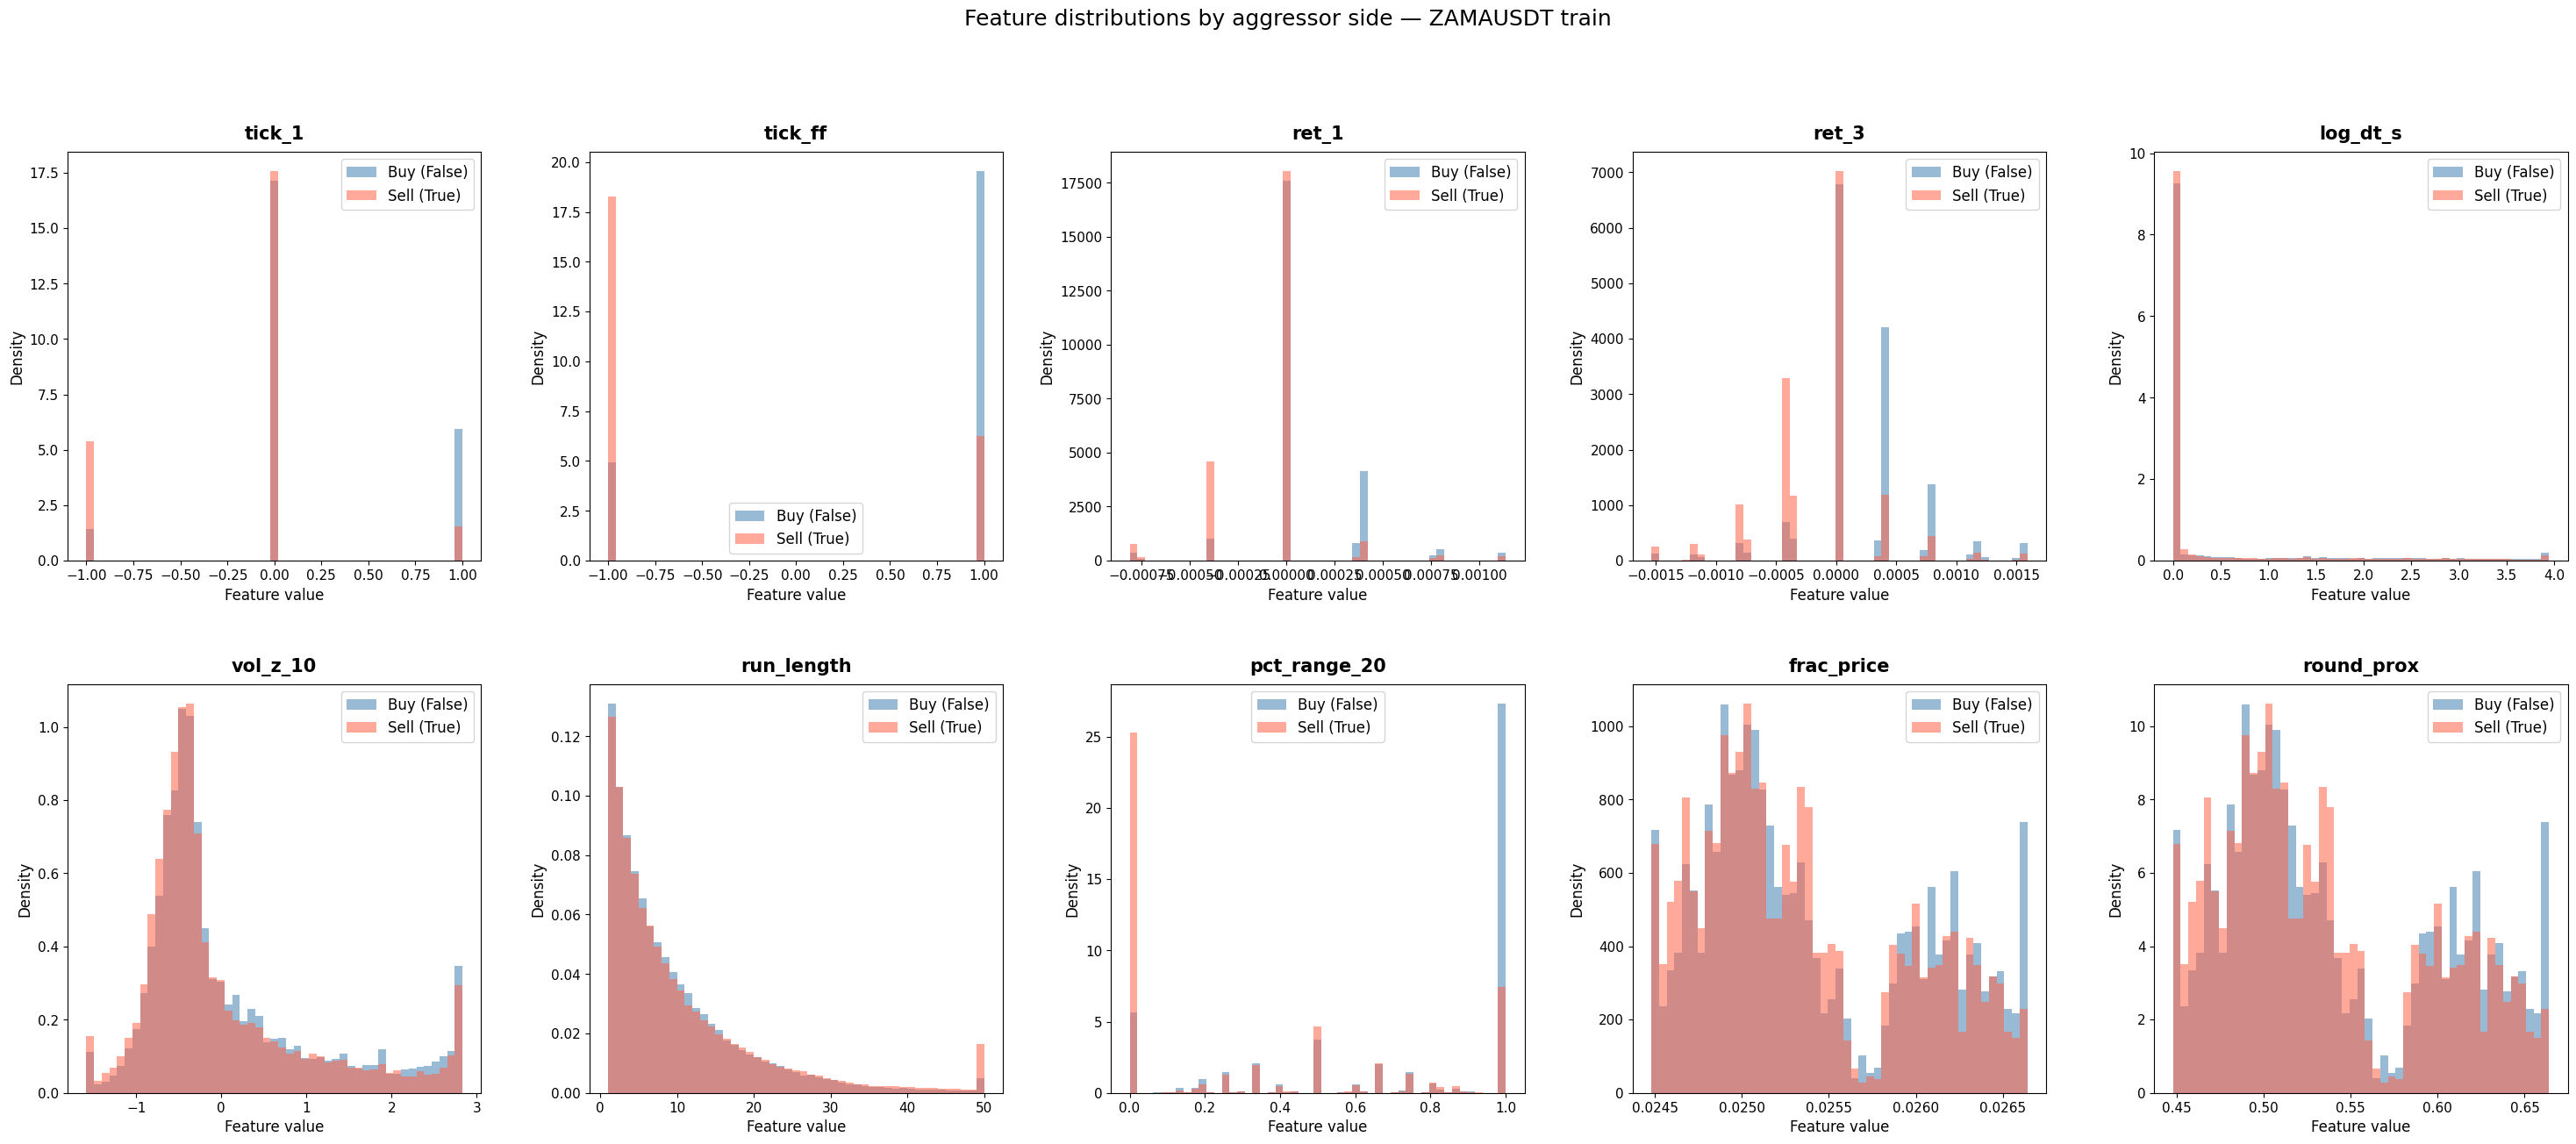

In [5]:
sym = 'ZAMAUSDT'
X_tr = feats_train[sym]
y_tr = train_data[sym]['side'].astype(bool)

KEY_FEATURES = ['tick_1', 'tick_ff', 'ret_1', 'ret_3', 'log_dt_s',
                'vol_z_10', 'run_length', 'pct_range_20', 'frac_price', 'round_prox']

fig, axes = plt.subplots(2, 5, figsize=(30, 13))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    col = X_tr[feat].dropna()
    y_aligned = y_tr.reindex(col.index)
    lo, hi = col.quantile(0.01), col.quantile(0.99)
    bins = np.linspace(lo, hi, 50) if hi > lo else 30
    ax.hist(col[~y_aligned].clip(lo, hi), bins=bins, alpha=0.55,
            label='Buy (False)', density=True, color='steelblue')
    ax.hist(col[ y_aligned].clip(lo, hi), bins=bins, alpha=0.55,
            label='Sell (True)', density=True, color='tomato')
    ax.set_title(feat, fontsize=15, fontweight='bold', pad=10)
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=11)
    ax.set_xlabel('Feature value', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)

fig.suptitle(f'Feature distributions by aggressor side — {sym} train', fontsize=18, y=1.02)
fig.tight_layout(pad=3.0, h_pad=4.5, w_pad=3.0)
plt.show()

## 4. Point-biserial correlation with the label

A quick **linear** measure of how strongly each feature predicts sell-aggressor (`True`).
We average |*r*| across both symbols so a feature only ranks high if it generalises.
High |*r*| = strong linear signal; near 0 = no linear signal (though a tree may still use it).

In [6]:
records = []
for sym in SYMBOLS:
    X = feats_train[sym]
    y = train_data[sym]['side'].astype(bool)
    for feat in FEATURE_NAMES:
        col = X[feat]
        mask = col.notna()
        if mask.sum() < 50:
            continue
        r, p = pointbiserialr(y[mask], col[mask])
        records.append({'symbol': sym, 'feature': feat, 'r': r, '|r|': abs(r)})

corr_df = pd.DataFrame(records)
pivot = corr_df.pivot(index='feature', columns='symbol', values='r')
pivot['mean_|r|'] = corr_df.groupby('feature')['|r|'].mean()
pivot = pivot.sort_values('mean_|r|', ascending=False)
print(pivot.to_string(float_format='{:.4f}'.format))

symbol        WIFUSDT  ZAMAUSDT  mean_|r|
feature                                  
pct_range_20  -0.5429   -0.4587    0.5008
tick_ff       -0.3660   -0.5385    0.4522
run_dir       -0.3660   -0.5385    0.4522
pct_range_50  -0.4720   -0.3607    0.4163
tick_5        -0.2891   -0.4175    0.3533
ret_10        -0.3421   -0.3509    0.3465
tick_4        -0.2733   -0.4176    0.3455
tick_3        -0.2579   -0.4061    0.3320
ret_5         -0.2890   -0.3512    0.3201
tick_2        -0.2334   -0.3779    0.3056
ret_3         -0.2579   -0.3264    0.2922
tick_1        -0.2050   -0.3130    0.2590
ret_1         -0.2050   -0.2491    0.2270
run_length    -0.1009    0.0532    0.0770
log_dt_s       0.0934   -0.0431    0.0683
log_amount    -0.0164   -0.0924    0.0544
frac_price    -0.0218   -0.0596    0.0407
log_price     -0.0220   -0.0592    0.0406
vol_z_20      -0.0152   -0.0562    0.0357
vol_z_50      -0.0268   -0.0440    0.0354
vol_z_10      -0.0123   -0.0529    0.0326
round_prox     0.0036   -0.0596   

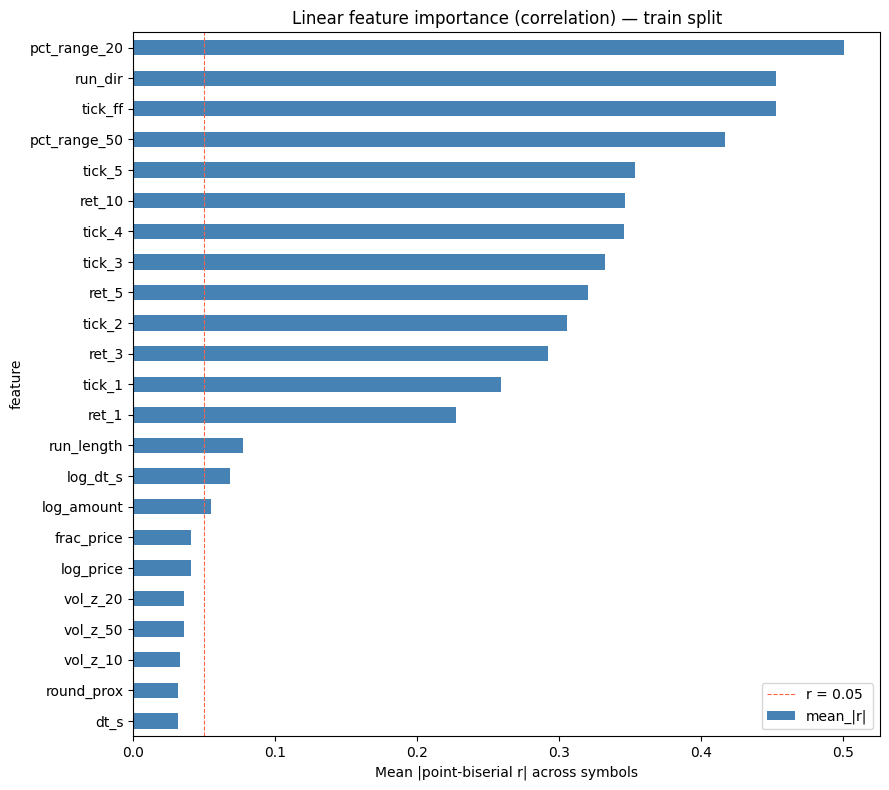

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
pivot['mean_|r|'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Mean |point-biserial r| across symbols')
ax.set_title('Linear feature importance (correlation) — train split')
ax.axvline(0.05, color='tomato', linestyle='--', linewidth=0.8, label='r = 0.05')
ax.legend()
plt.tight_layout()
plt.show()

## 5. LightGBM feature importance (non-linear)

Correlation only sees linear signal. We train a quick LightGBM on **ZAMAUSDT train**, evaluate on **ZAMAUSDT val**,
and read off **gain importance** — how much each feature reduced the loss across all its splits. This captures
interactions a linear measure misses.

*(Benek will do full hyper-parameter tuning later in `src/models/gbm.py`; this is just a signal check.)*

In [8]:
sym = 'ZAMAUSDT'
X_tr = feats_train[sym][FEATURE_NAMES]
y_tr = train_data[sym]['side'].astype(int)   # 0 = buy, 1 = sell
X_va = feats_val[sym][FEATURE_NAMES]
y_va = val_data[sym]['side'].astype(int)

mask_tr = X_tr.notna().all(axis=1)
mask_va = X_va.notna().all(axis=1)

dtrain = lgb.Dataset(X_tr[mask_tr], label=y_tr[mask_tr])
dval   = lgb.Dataset(X_va[mask_va], label=y_va[mask_va], reference=dtrain)

model = lgb.train(
    LGB_PARAMS, dtrain, num_boost_round=300, valid_sets=[dval],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)],
)

pred_va = pd.Series(model.predict(X_va[mask_va]) >= 0.5, index=X_va[mask_va].index)
m = metrics(val_data[sym]['side'][mask_va].astype(bool), pred_va)
print(f"LightGBM on {sym} val  (best_iteration = {model.best_iteration}):")
print(f"  accuracy={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}  bal_acc={m['balanced_accuracy']:.4f}")
tick_m = metrics(val_data[sym]['side'].astype(bool), tick_rule(val_data[sym]))
print(f"  (tick-rule baseline: acc={tick_m['accuracy']:.4f}  macro_f1={tick_m['macro_f1']:.4f})")

LightGBM on ZAMAUSDT val  (best_iteration = 95):
  accuracy=0.8117  macro_f1=0.8092  bal_acc=0.8077
  (tick-rule baseline: acc=0.7973  macro_f1=0.7971)


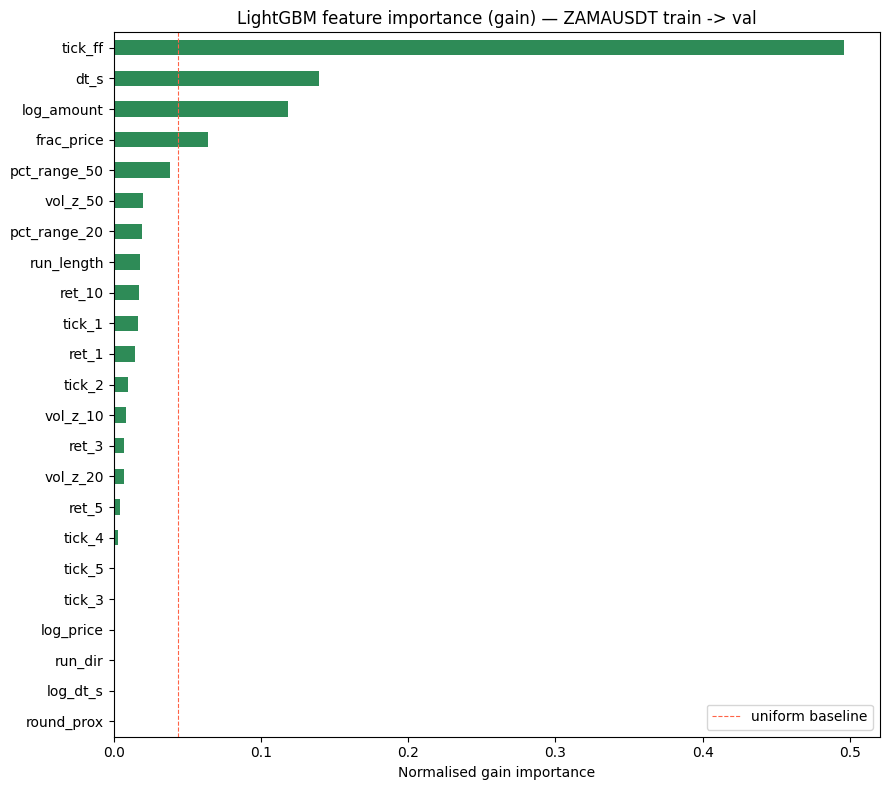

Top 10 by gain:
tick_ff         49.6%
dt_s            13.9%
log_amount      11.8%
frac_price       6.4%
pct_range_50     3.8%
vol_z_50         2.0%
pct_range_20     1.9%
run_length       1.8%
ret_10           1.7%
tick_1           1.6%


In [9]:
fi = pd.Series(model.feature_importance('gain'), index=FEATURE_NAMES)
fi_norm = (fi / fi.sum()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
fi_norm.sort_values().plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('Normalised gain importance')
ax.set_title(f'LightGBM feature importance (gain) — {sym} train -> val')
ax.axvline(1 / len(FEATURE_NAMES), color='tomato', linestyle='--', linewidth=0.8, label='uniform baseline')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 by gain:')
print(fi_norm.head(10).apply(lambda x: f'{x*100:.1f}%').to_string())

## 6. Ablation — drop the low-signal features

Keep only features with ≥ 1% normalised gain, retrain, and compare. If accuracy barely moves, the dropped features
were noise and the reduced set is preferable (faster, less overfitting).

In [10]:
THRESHOLD = 0.01
keep_feats = fi_norm[fi_norm >= THRESHOLD].index.tolist()
drop_feats = fi_norm[fi_norm <  THRESHOLD].index.tolist()

print(f"Keeping {len(keep_feats)} features (>= {THRESHOLD*100:.0f}% gain):\n  {keep_feats}")
print(f"\nDropping {len(drop_feats)} features:\n  {drop_feats}")

Keeping 11 features (>= 1% gain):
  ['tick_ff', 'dt_s', 'log_amount', 'frac_price', 'pct_range_50', 'vol_z_50', 'pct_range_20', 'run_length', 'ret_10', 'tick_1', 'ret_1']

Dropping 12 features:
  ['tick_2', 'vol_z_10', 'ret_3', 'vol_z_20', 'ret_5', 'tick_4', 'tick_5', 'tick_3', 'log_price', 'log_dt_s', 'run_dir', 'round_prox']


In [11]:
X_tr_r = feats_train[sym][keep_feats]
X_va_r = feats_val[sym][keep_feats]
mask_tr_r = X_tr_r.notna().all(axis=1)
mask_va_r = X_va_r.notna().all(axis=1)

dtrain_r = lgb.Dataset(X_tr_r[mask_tr_r], label=y_tr[mask_tr_r])
dval_r   = lgb.Dataset(X_va_r[mask_va_r], label=y_va[mask_va_r], reference=dtrain_r)
model_r = lgb.train(
    LGB_PARAMS, dtrain_r, num_boost_round=300, valid_sets=[dval_r],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)],
)

pred_r = pd.Series(model_r.predict(X_va_r[mask_va_r]) >= 0.5, index=X_va_r[mask_va_r].index)
m_r = metrics(val_data[sym]['side'][mask_va_r].astype(bool), pred_r)
print(f"Reduced set ({len(keep_feats)} features):  acc={m_r['accuracy']:.4f}  macro_f1={m_r['macro_f1']:.4f}")
print(f"Full set    ({len(FEATURE_NAMES)} features):  acc={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}")
print(f"Delta:  d_acc={m_r['accuracy']-m['accuracy']:+.4f}   d_macro_f1={m_r['macro_f1']-m['macro_f1']:+.4f}")

Reduced set (11 features):  acc=0.8048  macro_f1=0.8018
Full set    (23 features):  acc=0.8117  macro_f1=0.8092
Delta:  d_acc=-0.0069   d_macro_f1=-0.0074


## 7. Cross-symbol generalisation

The professor evaluates on **unseen data**. Our closest proxy is to train on one symbol and test on the other.
We compare four setups against the tick-rule baseline:
- **cross**: train on A, test on B (the hard case)
- **same**: train on A, test on A's next day (the easy case)

A large cross vs same gap means the model has latched onto symbol-specific quirks rather than general microstructure.

In [12]:
def fit_eval(train_sym, test_sym, n_rounds):
    Xa = feats_train[train_sym][FEATURE_NAMES]; ya = train_data[train_sym]['side'].astype(int)
    Xb = feats_val[test_sym][FEATURE_NAMES];    yb = val_data[test_sym]['side'].astype(bool)
    ma = Xa.notna().all(axis=1); mb = Xb.notna().all(axis=1)
    mdl = lgb.train(LGB_PARAMS, lgb.Dataset(Xa[ma], label=ya[ma]),
                    num_boost_round=n_rounds, callbacks=[lgb.log_evaluation(False)])
    pred = pd.Series(mdl.predict(Xb[mb]) >= 0.5, index=Xb[mb].index)
    return metrics(yb[mb], pred)

n_rounds = model.best_iteration
rows = []
for a, b, kind in [('ZAMAUSDT', 'WIFUSDT', 'cross'), ('WIFUSDT', 'ZAMAUSDT', 'cross'),
                   ('WIFUSDT', 'WIFUSDT', 'same'),  ('ZAMAUSDT', 'ZAMAUSDT', 'same')]:
    r = fit_eval(a, b, n_rounds)
    rows.append({'setup': f'{a} -> {b}', 'kind': kind,
                 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1']})

for sym in SYMBOLS:
    tk = metrics(val_data[sym]['side'].astype(bool), tick_rule(val_data[sym]))
    rows.append({'setup': f'tick-rule {sym}', 'kind': 'baseline',
                 'accuracy': tk['accuracy'], 'macro_f1': tk['macro_f1']})

cross_df = pd.DataFrame(rows).set_index('setup')
print(cross_df.to_string(float_format='{:.4f}'.format))

                          kind  accuracy  macro_f1
setup                                             
ZAMAUSDT -> WIFUSDT      cross    0.6467    0.6348
WIFUSDT -> ZAMAUSDT      cross    0.7541    0.7541
WIFUSDT -> WIFUSDT        same    0.6761    0.6745
ZAMAUSDT -> ZAMAUSDT      same    0.8117    0.8092
tick-rule WIFUSDT     baseline    0.7082    0.7082
tick-rule ZAMAUSDT    baseline    0.7973    0.7971


### Results & interpretation

*(numbers below are from the deterministic run — `num_threads=1`, `SEED=42`)*

| Setup | Accuracy | Macro F1 |
|---|---|---|
| ZAMAUSDT → WIFUSDT (cross) | 0.6467 | 0.6348 |
| WIFUSDT → ZAMAUSDT (cross) | 0.7541 | 0.7541 |
| WIFUSDT → WIFUSDT (same) | 0.6761 | 0.6745 |
| ZAMAUSDT → ZAMAUSDT (same) | 0.8117 | 0.8092 |
| tick-rule WIFUSDT | 0.7082 | 0.7082 |
| tick-rule ZAMAUSDT | 0.7973 | 0.7971 |

**1. Cross-symbol transfer costs ~6pp — moderate, not catastrophic.**  
ZAMA→WIF drops from 0.676 (same) to 0.647; WIF→ZAMA drops from 0.812 (same) to 0.754. The model keeps most of its skill
across symbols, which is encouraging for the professor's unseen-data evaluation.

**2. The real weak spot is WIFUSDT, not cross-symbol transfer.**  
Even trained *on itself*, the GBM on WIFUSDT (0.676) **loses to the WIFUSDT tick rule (0.708)**. WIFUSDT has only ~10.8k
training rows — too few for LightGBM to beat a hand rule. ZAMAUSDT (31k rows) comfortably beats its tick rule
(0.812 vs 0.797). So the bottleneck for WIFUSDT is **training-data volume**, addressable by pooling both symbols.

**3. `frac_price` is a transfer risk worth watching.**  
It is the 4th-most-important feature (~6% gain) yet is a *price-level* feature tied to each symbol's absolute price
(ZAMAUSDT ≈ \$0.025). It cannot mean the same thing on a different instrument, so it likely contributes to the
cross-symbol drop. Worth ablating in the final model to verify.

**Implications for the final classifier:**
- **Train on both symbols pooled** — fixes WIFUSDT's data-starvation and improves robustness.
- **Test dropping price-level features** (`frac_price`, `round_prox`, `log_price`); keep price-*relative* ones (`pct_range_*`, `ret_*`).
- The **sequence model** may help most on the small-data symbol by sharing temporal structure.

## 8. Summary

**Correlation (Section 4).** Strongest linear signals: `pct_range_20` (|r| ≈ 0.50), `tick_ff` / `run_dir` (≈ 0.45),
`pct_range_50` (≈ 0.42), then the longer tick lags and `ret_10`/`ret_5` (≈ 0.33–0.35). Volume, time and round-number
features are weak linearly (|r| < 0.10).

**LightGBM importance (Section 5).** On ZAMAUSDT val the quick GBM scores **acc 0.8117 / macro-F1 0.8092**, beating the
tick rule (0.7973 / 0.7971). Gain is dominated by `tick_ff` (~50%), then `dt_s` (~14%), `log_amount` (~12%) and
`frac_price` (~6%). Note how `dt_s` and `log_amount` rank high on gain despite near-zero linear correlation — the tree
uses them in interactions.

**Ablation (Section 6).** Keeping the 11 features with ≥1% gain costs only **−0.007 macro-F1** vs the full 23 — the
other 12 are essentially noise. Retained: `tick_ff`, `dt_s`, `log_amount`, `frac_price`, `pct_range_50`, `vol_z_50`,
`pct_range_20`, `run_length`, `ret_10`, `tick_1`, `ret_1`.

**Cross-symbol (Section 7).** Transfer costs ~6pp (moderate). The genuine problem is **WIFUSDT's small training set**:
even same-symbol it can't beat its tick rule (0.676 < 0.708), whereas ZAMAUSDT can (0.812 > 0.797). *(The earlier
"catastrophic" 0.55 cross result was a non-deterministic-seed artifact, now fixed via `num_threads=1`.)*

**Recommendations for the GBM and sequence models**
1. **Core feature set:** `tick_ff`, `pct_range_20`, `pct_range_50`, `run_length`, `ret_1`, `ret_3`, `ret_10`, `dt_s`, `log_amount`, `vol_z_50`.
2. **Drop for cross-symbol robustness (test first):** `frac_price`, `round_prox`, `log_price`.
3. **Train on both symbols pooled** — essential for WIFUSDT.
4. Hand off this feature set to `src/models/gbm.py` (Benek) and `src/models/sequence.py` (Krzysiek).